Лабораторная работа 2  
ФИО: Тавуз_Мохамад  
Группа: ИУ5И-22М  
Тема: «Обработка признаков (часть 2)»

Набор данных: Titanic (Data Science Dojo)

## Импорт необходимых библиотек

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')

print("Libraries imported successfully")

Libraries imported successfully


## Загрузка набора данных Titanic и просмотр первых строк

In [2]:
# Загрузка набора данных Titanic
df = sns.load_dataset('titanic')

# Просмотр первых строк
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Анализ структуры данных и проверка пропущенных значений

In [3]:
# Общая информация о наборе данных
df.info()

print("\n========================\n")

# Проверка количества пропущенных значений в каждом столбце
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
s

## Обработка пропущенных значений

In [4]:
# Создание копии исходного набора данных для дальнейшей обработки
df_processed = df.copy()

# Заполнение пропущенных значений в числовом признаке age медианой
df_processed['age'].fillna(df_processed['age'].median(), inplace=True)

# Заполнение пропущенных значений в категориальных признаках модой
df_processed['embarked'].fillna(df_processed['embarked'].mode()[0], inplace=True)
df_processed['embark_town'].fillna(df_processed['embark_town'].mode()[0], inplace=True)

# Удаление признака deck, так как он содержит слишком много пропущенных значений
df_processed.drop(columns=['deck'], inplace=True)

# Проверка результата обработки пропущенных значений
df_processed.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


## Масштабирование числовых признаков с использованием Min-Max Scaling

In [5]:
# Выбор числовых признаков для масштабирования
numeric_cols = ['age', 'fare']

# Создание объекта MinMaxScaler
minmax_scaler = MinMaxScaler()

# Создание копии данных
df_minmax = df_processed.copy()

# Масштабирование признаков
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df_minmax[numeric_cols])

# Просмотр результата
df_minmax[numeric_cols].head()

,age,fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


## Визуализация признаков после Min-Max Scaling

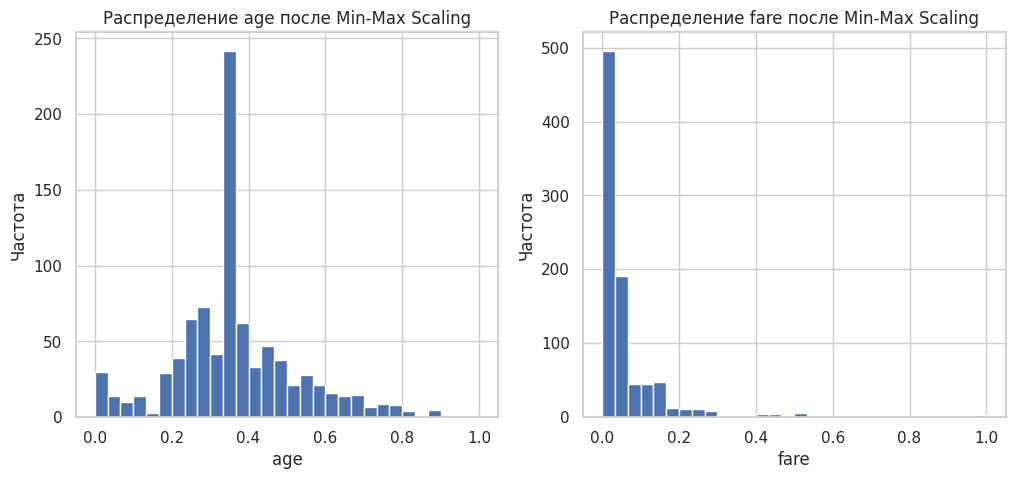

In [6]:
# Построение гистограмм после Min-Max Scaling
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_minmax['age'], bins=30)
plt.title('Распределение age после Min-Max Scaling')
plt.xlabel('age')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(df_minmax['fare'], bins=30)
plt.title('Распределение fare после Min-Max Scaling')
plt.xlabel('fare')
plt.ylabel('Частота')

plt.show()

## Масштабирование числовых признаков с использованием StandardScaler

In [7]:
# Создание объекта StandardScaler
standard_scaler = StandardScaler()

# Создание копии данных
df_standard = df_processed.copy()

# Масштабирование признаков
df_standard[numeric_cols] = standard_scaler.fit_transform(df_standard[numeric_cols])

# Просмотр результата
df_standard[numeric_cols].head()

,age,fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


## Визуализация признаков после StandardScaler

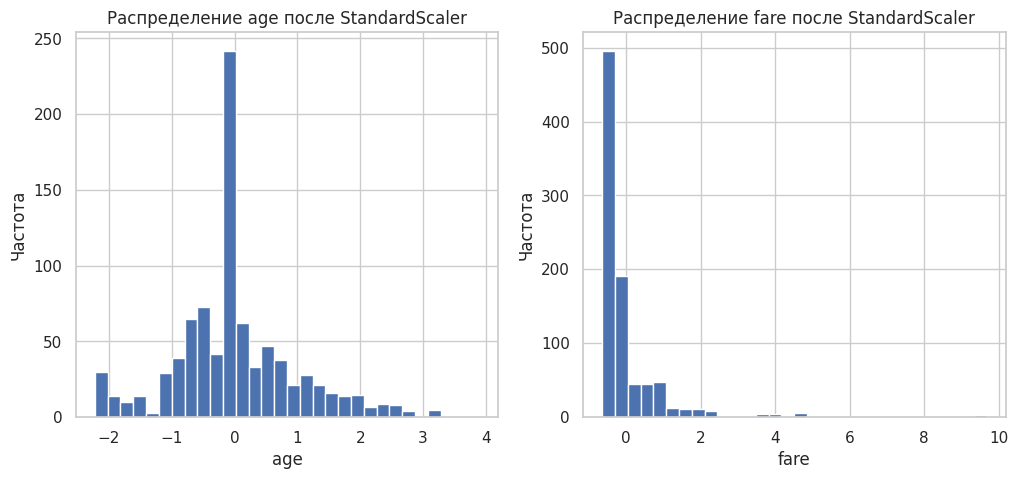

In [8]:
# Построение гистограмм после StandardScaler
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_standard['age'], bins=30)
plt.title('Распределение age после StandardScaler')
plt.xlabel('age')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(df_standard['fare'], bins=30)
plt.title('Распределение fare после StandardScaler')
plt.xlabel('fare')
plt.ylabel('Частота')

plt.show()

## Масштабирование числовых признаков с использованием RobustScaler

In [9]:
# Создание объекта RobustScaler
robust_scaler = RobustScaler()

# Создание копии данных
df_robust = df_processed.copy()

# Масштабирование признаков
df_robust[numeric_cols] = robust_scaler.fit_transform(df_robust[numeric_cols])

# Просмотр результата
df_robust[numeric_cols].head()

,age,fare
0,-0.461538,-0.312011
1,0.769231,2.461242
2,-0.153846,-0.282777
3,0.538462,1.673732
4,0.538462,-0.277363


## Визуализация признаков после RobustScaler

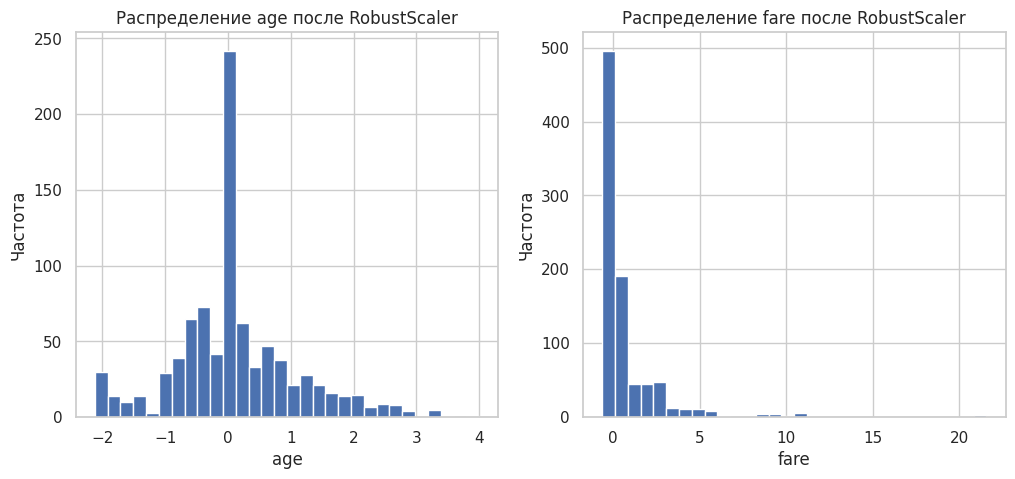

In [10]:
# Построение гистограмм после RobustScaler
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_robust['age'], bins=30)
plt.title('Распределение age после RobustScaler')
plt.xlabel('age')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
plt.hist(df_robust['fare'], bins=30)
plt.title('Распределение fare после RobustScaler')
plt.xlabel('fare')
plt.ylabel('Частота')

plt.show()

## Анализ выбросов в числовых признаках

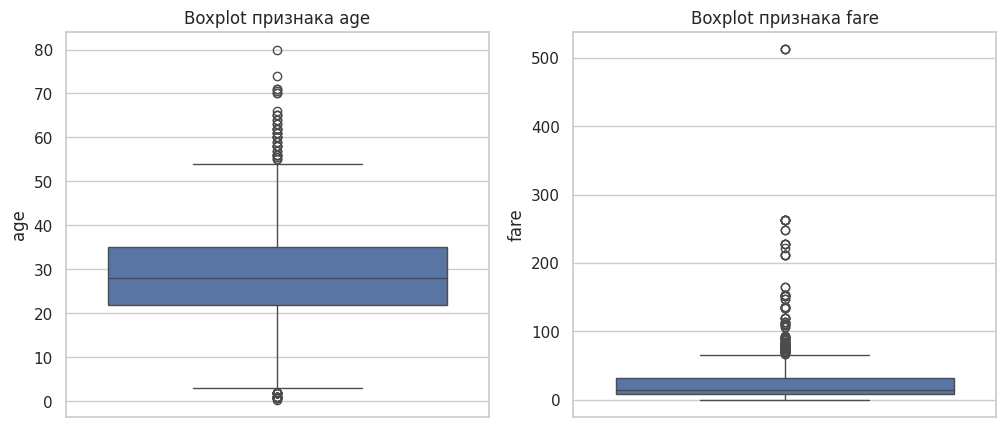

In [11]:
# Построение boxplot для анализа выбросов в признаках age и fare
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_processed['age'])
plt.title('Boxplot признака age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_processed['fare'])
plt.title('Boxplot признака fare')

plt.show()

## Удаление выбросов методом межквартильного размаха IQR

In [12]:
# Расчет квартилей и межквартильного размаха для признака fare
Q1 = df_processed['fare'].quantile(0.25)
Q3 = df_processed['fare'].quantile(0.75)
IQR = Q3 - Q1

# Определение нижней и верхней границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Удаление строк, в которых fare выходит за допустимые границы
df_removed_outliers = df_processed[
    (df_processed['fare'] >= lower_bound) &
    (df_processed['fare'] <= upper_bound)
]

# Вывод количества строк до и после удаления выбросов
print("Количество строк до удаления выбросов:", df_processed.shape[0])
print("Количество строк после удаления выбросов:", df_removed_outliers.shape[0])
print("Количество удаленных строк:", df_processed.shape[0] - df_removed_outliers.shape[0])
print("Нижняя граница:", lower_bound)
print("Верхняя граница:", upper_bound)

Количество строк до удаления выбросов: 891
Количество строк после удаления выбросов: 775
Количество удаленных строк: 116
Нижняя граница: -26.724
Верхняя граница: 65.6344


## Визуализация признака fare после удаления выбросов

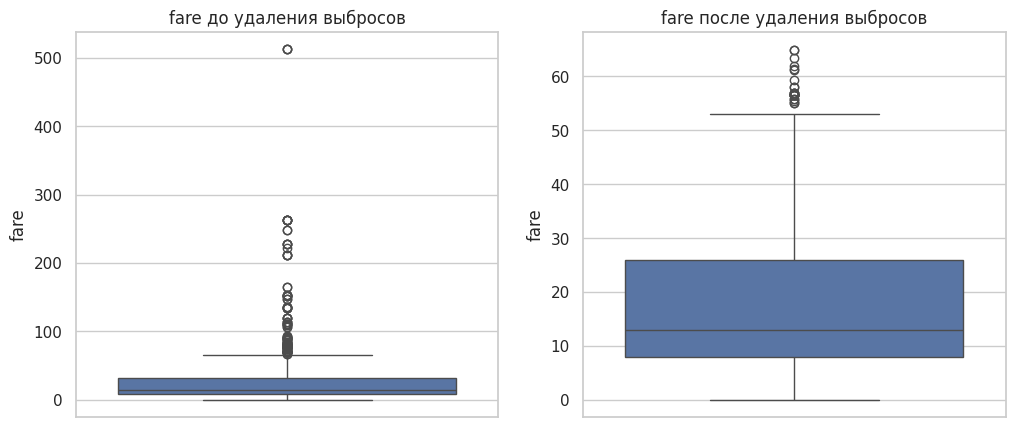

In [13]:
# Сравнение boxplot признака fare до и после удаления выбросов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_processed['fare'])
plt.title('fare до удаления выбросов')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_removed_outliers['fare'])
plt.title('fare после удаления выбросов')

plt.show()

## Замена выбросов методом ограничения значений clipping

In [14]:
# Создание копии данных для замены выбросов
df_replaced_outliers = df_processed.copy()

# Замена выбросов в признаке fare на нижнюю и верхнюю границы
df_replaced_outliers['fare'] = df_replaced_outliers['fare'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Вывод статистики до и после замены выбросов
print("Максимальное значение fare до замены:", df_processed['fare'].max())
print("Максимальное значение fare после замены:", df_replaced_outliers['fare'].max())

print("Минимальное значение fare до замены:", df_processed['fare'].min())
print("Минимальное значение fare после замены:", df_replaced_outliers['fare'].min())

Максимальное значение fare до замены: 512.3292
Максимальное значение fare после замены: 65.6344
Минимальное значение fare до замены: 0.0
Минимальное значение fare после замены: 0.0


## Визуализация признака fare после замены выбросов

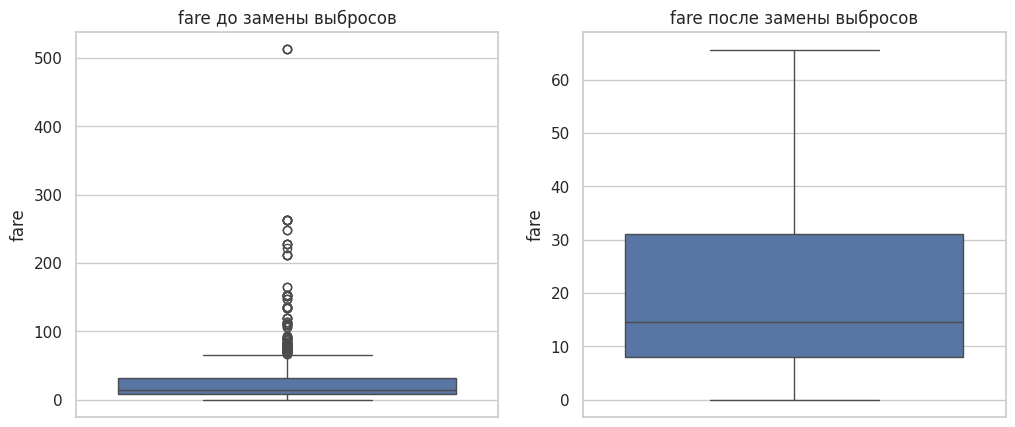

In [15]:
# Сравнение boxplot признака fare до и после замены выбросов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_processed['fare'])
plt.title('fare до замены выбросов')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_replaced_outliers['fare'])
plt.title('fare после замены выбросов')

plt.show()

## Обработка нестандартного текстового признака embark_town

In [16]:
# Создание копии данных для обработки нестандартного признака
df_text_feature = df_replaced_outliers.copy()

# Формирование нового признака: длина названия города посадки
df_text_feature['embark_town_length'] = df_text_feature['embark_town'].astype(str).apply(len)

# Формирование нового признака: первая буква названия города посадки
df_text_feature['embark_town_first_letter'] = df_text_feature['embark_town'].astype(str).str[0]

# Просмотр результата
df_text_feature[['embark_town', 'embark_town_length', 'embark_town_first_letter']].head()

,embark_town,embark_town_length,embark_town_first_letter
0,Southampton,11,S
1,Cherbourg,9,C
2,Southampton,11,S
3,Southampton,11,S
4,Southampton,11,S


## Визуализация нового признака embark_town_length

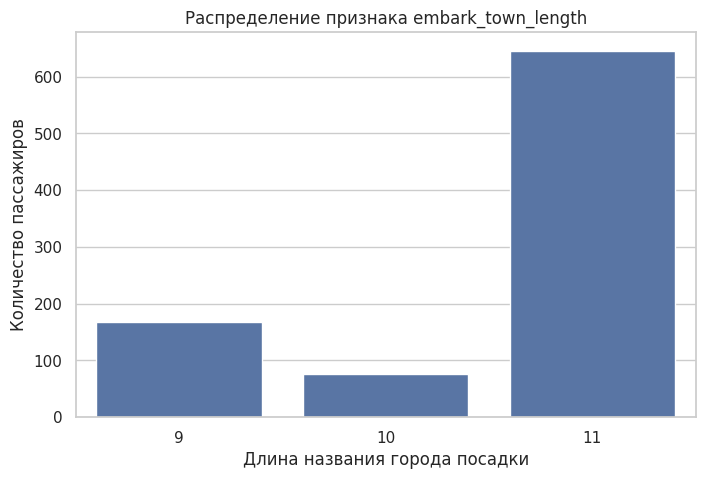

In [17]:
# Построение графика распределения длины названия города посадки
plt.figure(figsize=(8, 5))

sns.countplot(x='embark_town_length', data=df_text_feature)
plt.title('Распределение признака embark_town_length')
plt.xlabel('Длина названия города посадки')
plt.ylabel('Количество пассажиров')

plt.show()

## Подготовка данных для отбора признаков

In [18]:
# Создание копии данных для отбора признаков
df_features = df_text_feature.copy()

# Удаление признака alive, так как он напрямую дублирует целевую переменную survived
df_features.drop(columns=['alive'], inplace=True)

# Преобразование булевых признаков в числовой формат
bool_cols = df_features.select_dtypes(include=['bool']).columns
df_features[bool_cols] = df_features[bool_cols].astype(int)

# Кодирование категориальных и текстовых признаков методом One-Hot Encoding
df_features_encoded = pd.get_dummies(df_features, drop_first=True)

# Разделение данных на признаки X и целевую переменную y
X = df_features_encoded.drop(columns=['survived'])
y = df_features_encoded['survived']

# Просмотр размерности данных после кодирования
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)

# Просмотр первых строк подготовленных данных
X.head()

Размерность X: (891, 19)
Размерность y: (891,)


,pclass,age,sibsp,parch,fare,adult_male,alone,embark_town_length,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,embark_town_first_letter_Q,embark_town_first_letter_S
0,3,22.0,1,0,7.2500,1,0,11,True,False,True,False,True,True,False,False,True,False,True
1,1,38.0,1,0,65.6344,0,0,9,False,False,False,False,False,False,True,False,False,False,False
2,3,26.0,0,0,7.9250,0,1,11,False,False,True,False,True,False,True,False,True,False,True
3,1,35.0,1,0,53.1000,0,0,11,False,False,True,False,False,False,True,False,True,False,True
4,3,35.0,0,0,8.0500,1,1,11,True,False,True,False,True,True,False,False,True,False,True


## Отбор признаков методом фильтрации SelectKBest

In [19]:
# Преобразование всех признаков в числовой формат
X_numeric = X.astype(int)

# Создание объекта SelectKBest для выбора 5 лучших признаков
filter_selector = SelectKBest(score_func=f_classif, k=5)

# Обучение метода фильтрации
X_filter_selected = filter_selector.fit_transform(X_numeric, y)

# Получение выбранных признаков
filter_selected_features = X_numeric.columns[filter_selector.get_support()]

# Вывод выбранных признаков
print("Выбранные признаки методом SelectKBest:")
print(list(filter_selected_features))

Выбранные признаки методом SelectKBest:
['pclass', 'adult_male', 'sex_male', 'who_man', 'who_woman']


## Отбор признаков методом обертывания RFE

In [20]:
# Создание модели логистической регрессии для метода RFE
rfe_model = LogisticRegression(max_iter=1000)

# Создание объекта RFE для выбора 5 лучших признаков
rfe_selector = RFE(estimator=rfe_model, n_features_to_select=5)

# Обучение метода RFE
rfe_selector.fit(X_numeric, y)

# Получение выбранных признаков
rfe_selected_features = X_numeric.columns[rfe_selector.support_]

# Вывод выбранных признаков
print("Выбранные признаки методом RFE:")
print(list(rfe_selected_features))

Выбранные признаки методом RFE:
['pclass', 'sibsp', 'adult_male', 'alone', 'who_man']


## Отбор признаков методом вложений RandomForestClassifier

In [21]:
# Создание модели RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Обучение модели
rf_model.fit(X_numeric, y)

# Получение важности признаков
feature_importances = pd.DataFrame({
    'Признак': X_numeric.columns,
    'Важность': rf_model.feature_importances_
})

# Сортировка признаков по важности
feature_importances = feature_importances.sort_values(
    by='Важность',
    ascending=False
)

# Выбор 5 наиболее важных признаков
embedded_selected_features = feature_importances.head(5)

# Вывод результата
print("Выбранные признаки методом RandomForestClassifier:")
print(list(embedded_selected_features['Признак']))

embedded_selected_features

Выбранные признаки методом RandomForestClassifier:
['age', 'fare', 'adult_male', 'who_man', 'sex_male']


,Признак,Важность
1,age,0.259963
4,fare,0.168553
5,adult_male,0.109671
13,who_man,0.092559
8,sex_male,0.087445


## Визуализация важности признаков RandomForestClassifier

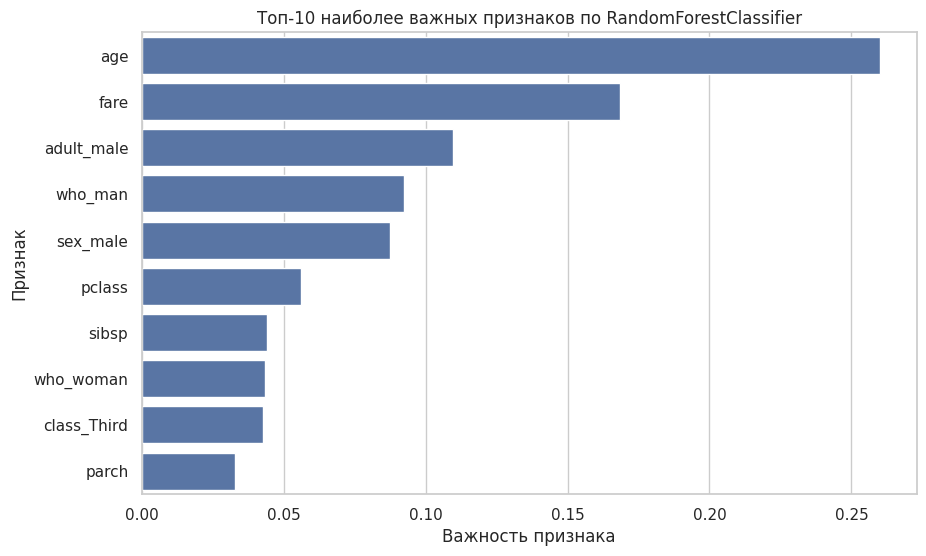

In [22]:
# Построение графика важности признаков
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Важность',
    y='Признак',
    data=feature_importances.head(10)
)

plt.title('Топ-10 наиболее важных признаков по RandomForestClassifier')
plt.xlabel('Важность признака')
plt.ylabel('Признак')

plt.show()

## Итоговый вывод

В ходе лабораторной работы были выполнены продвинутые этапы предварительной обработки данных на наборе Titanic. Были применены три метода масштабирования числовых признаков: MinMaxScaler, StandardScaler и RobustScaler. Для обработки выбросов в признаке fare использовались два подхода: удаление выбросов методом IQR и замена выбросов методом ограничения значений clipping.

Также был обработан нестандартный текстовый признак embark_town: на его основе были сформированы новые признаки embark_town_length и embark_town_first_letter. На заключительном этапе был выполнен отбор признаков тремя методами: SelectKBest как метод фильтрации, RFE как метод обертывания и RandomForestClassifier как метод вложений.

Полученные результаты показывают, что наиболее значимыми признаками для предсказания выживаемости пассажира являются age, fare, adult_male, who_man, sex_male и pclass.